# Wakefield under uncertainty

> **Uncertainty quantification plugs into every analysis.** A run is deterministic until you add a `uq_config`; with it, the analysis is evaluated over a small Stroud-3 quadrature of the uncertain geometry and returns a distribution (mean, standard deviation). The same pattern works for eigenmode, tuning, wakefield, and optimisation.

Here the analysis is the **wakefield / impedance** solve (ABCI). The figure of merit is the peak longitudinal impedance $|Z_\parallel|$ in chosen frequency windows — a `ZL` objective, `[goal, 'ZL', [f0, f1, …]]`, whose windows are the consecutive pairs of the frequency list (GHz). With a `uq_config`, each window's peak comes back as a **mean ± standard deviation** over the perturbed geometries instead of a single number.

> Needs the bundled `ABCI.exe` (Windows, or `wine` elsewhere). ABCI needs beam pipes at both ends, so the cavity is built with `beampipe='both'`. See the [wakefield guide](../../wakefield) and the deterministic [wakefield example](../wakefield/impedance.ipynb).

In [1]:
import os
import tempfile

import pandas as pd
import matplotlib.pyplot as plt

from cavsim2d import Cavities, EllipticalCavity
from cavsim2d.utils.style import apply_style

apply_style()

## 1. The cavity and the uncertainty

A TESLA-like mid-cell in a one-cavity study (UQ perturbs the geometry, so it runs through `Cavities`, not a bare `Cavity`). The `uq_config` puts a **5% spread** on the ellipse semi-axes `A, B` and asks for the `ZL` peaks in two windows: 0.2–2.0 GHz and 2.0–5.0 GHz.

In [2]:
cavs = Cavities(os.path.join(tempfile.mkdtemp(), 'wake_uq'))
midcell = [42, 42, 12, 19, 35, 57.7, 103.353]
cavs.add_cavity([EllipticalCavity(1, midcell, midcell, midcell, beampipe='both')], ['W'])

config = {
    'MROT': 2, 'wakelength': 20, 'bunch_length': 25, 'processes': 1,
    'uq_config': {
        'variables': ['A', 'B'],
        'objectives': [['min', 'ZL', [0.2, 2.0, 5.0]]],
        'method': ['stroud3'], 'delta': [0.05, 0.05], 'processes': 1,
        'cell_type': 'mid-cell', 'cell_complexity': 'simplecell',
    },
}

## 2. Run it

Every quadrature node is a full ABCI wakefield solve, so this is the slowest of the UQ examples — a handful of perturbed geometries, each a complete time-domain run.

In [3]:
cavs.run_wakefield(config)
uq = cavs.uq_hom_results['W']
print('windows:', list(uq))

windows: ['ZL [max(0.2<f<2.0)]', 'ZL [max(2.0<f<5.0)]']


## 3. The impedance spread

For each frequency window the result carries the **mean** `expe` and **standard deviation** `stdDev` of the peak $|Z_\parallel|$ across the perturbed geometries — the spread the tolerance band induces on the HOM impedance.

In [4]:
df = pd.DataFrame({
    window: {'E[ZL] [Ohm]': v['expe'][0], 'std[ZL] [Ohm]': v['stdDev'][0]}
    for window, v in uq.items()
}).T
df.round(2)

,E[ZL] [Ohm],std[ZL] [Ohm]
ZL [max(0.2<f<2.0)],12.69,0.04
ZL [max(2.0<f<5.0)],7.60,0.28


## 4. Plot the mean with its uncertainty band

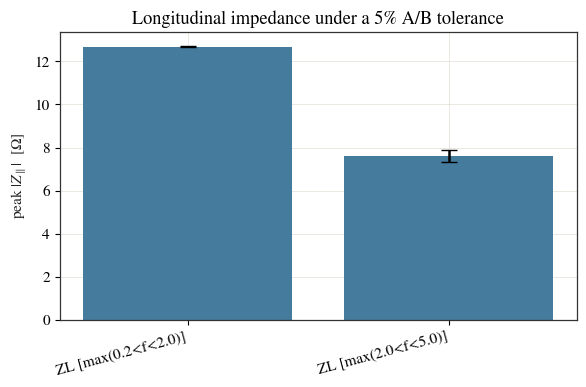

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = list(uq)
means = [uq[w]['expe'][0] for w in labels]
stds = [uq[w]['stdDev'][0] for w in labels]
ax.bar(range(len(labels)), means, yerr=stds, capsize=6)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel(r'peak $|Z_\parallel|$  [$\Omega$]')
ax.set_title('Longitudinal impedance under a 5% A/B tolerance')
fig.tight_layout()
plt.show()

See also: [eigenmode UQ](eigenmode_uq.ipynb), [robust tuning](robust_tuning.ipynb) and [robust optimisation](robust_optimisation.ipynb).